# Mathematical Tools


## Approximation

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

Throughout this section, the main example function is the following, which is com‐
prised of a trigonometric term and a linear term:

In [4]:
def f(x):
    return np.sin(x)+0.5*x 

Approximation of this function over a given interval by regres‐
sion and interpolation techniques. First, a plot of the function to get a better view of
what exactly the approximation shall achieve. The interval of interest shall be [–2π,
2π]. Figure 11-1 displays the function over the fixed interval defined via the np.lin
space() function. The function create_plot() is a helper function to create the
same type of plot required multiple times in this chapter

In [5]:
def create_plot(x,y,styles,labels,axlabels):
    plt.figure(figsize=(10,6))
    for i in range(len(x)):
        plt.plot(x[i],y[i],styles[i],label=labels[i])
        plt.xlabel(axlabels[0])
        plt.ylabel(axlabels[1])
    plt.legend()
    

In [6]:
x = np.linspace(-2*np.pi,2*np.pi,50)


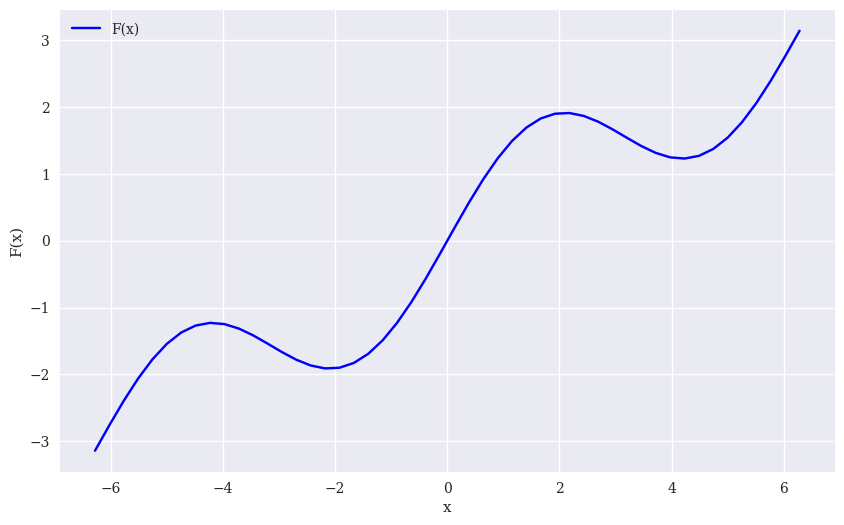

In [7]:
create_plot([x],[f(x)],['b'],['F(x)'],['x','F(x)'])

### Regression

Regression is a rather efficient tool when it comes to function approximation. It is
not only suited to approximating one-dimensional functions but also works well in
higher dimensions. The numerical techniques needed to come up with regression
results are easily implemented and quickly executed. Basically, the task of regression,
given a set of so-called basis functions bd
, d ∈ {1, . ⋯ , D}, is to find optimal param‐
eters α1
*
, ⋯ , αD
*
 according to Minimization problem of Regression, where yi ≡ f (xi) for i ∈ {1, ⋯ , I}
observation points. The xi
 are considered independent observations and the yi depen‐
dent observations (in a functional or statistical sense).

#### Monomials as basis functions

One of the simplest cases is to take monomials as basis functions—i.e.,
b1 = 1, b2 = x, b3 = x
2
, b4 = x
3
, ⋯ . In such a case, NumPy has built-in functions for
both the determination of the optimal parameters (namely, np.polyfit()) and the
evaluation of the approximation given a set of input values (namely, np.polyval())

In [8]:
# Linear Regression Step
res = np.polyfit(x,f(x),deg=1,full=True)
# x : x cordinate ( independent variable values)
# y : y cordinate (dependent variable values)
# deg : Degree of the fittig polynomial 
# full : if True , returns diagnostic information in addition
# w : wights to apply to the y cordinates 
# cov : if True, returns covariance matrix in addition

Given the returned
optimal regression coefficients p from np.polyfit(), np.polyval(p, x) then
returns the regression values for the x coordinates

In [9]:
# Full results , regressio parameters ,
#  residuals , effective ranks , singular values , and relative conditional number 
res

(array([ 4.28841952e-01, -5.49532361e-17]),
 array([21.03238686]),
 np.int32(2),
 array([1., 1.]),
 np.float64(1.1102230246251565e-14))

In [10]:
ry = np.polyval(res[0],x)

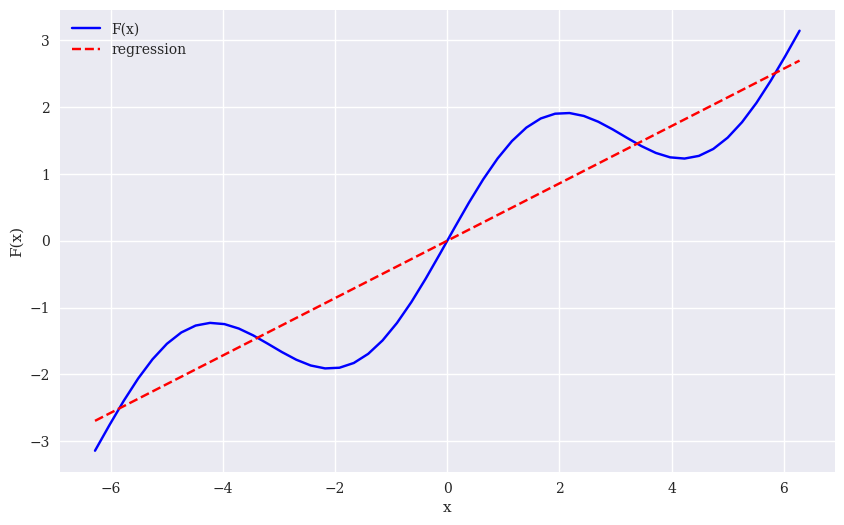

In [11]:
create_plot([x,x],[f(x),ry],['b','r--'],['F(x)','regression'],['x','F(x)'])

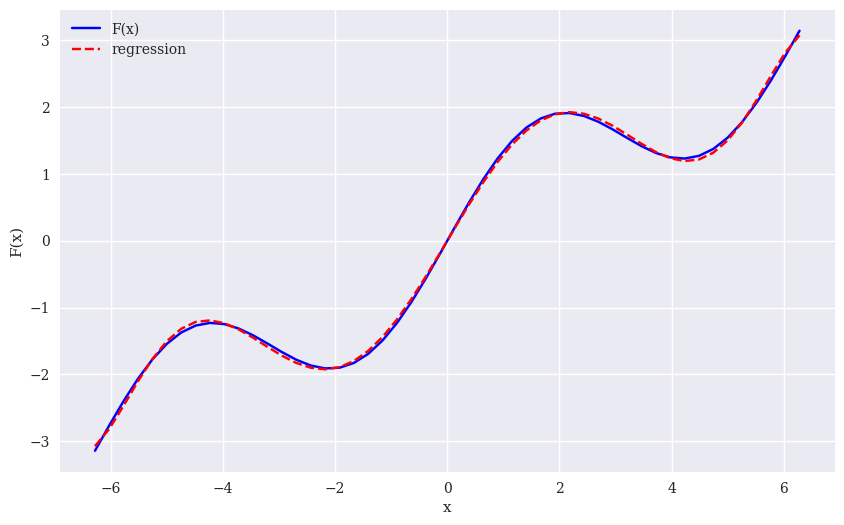

In [12]:
res = np.polyfit(x,f(x),deg=7,full=True)
ry = np.polyval(res[0],x)
create_plot([x,x],[f(x),ry],['b','r--'],['F(x)','regression'],['x','F(x)'])

Checks whether the function and regression values are the same (or at least
close)

In [ ]:
np.allclose(f(x),ry)


False

Calculates the Mean Squared Error (MSE) for the regression values given the
function values

In [14]:
np.mean((f(x)-ry)**2)

np.float64(0.00177691347595176)

### Individual basis function


In general, one can reach better regression results by choosing better sets of basis
functions, e.g., by exploiting knowledge about the function to approximate. In this
case, the individual basis functions have to be defined via a matrix approach (i.e.,
using a NumPy ndarray object). First, the case with monomials up to order 3
(Figure 11-5). The central function here is np.linalg.lstsq()

The basis function values from constant to cubic

In [16]:
matrix = np.zeros((3+1,len(x)))
matrix[3,:] = x ** 3
matrix[2,:] = x ** 2
matrix[1,:] = x 
matrix[0,:] = 1
matrix

array([[ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00],
       [-6.28

Regression Step 

In [19]:
reg = np.linalg.lstsq(matrix.T,f(x),rcond=None)[0]
reg

array([ 1.16778801e-14,  5.62777448e-01, -8.88178420e-16, -5.43553615e-03])

The optimal regression parameters

In [20]:
reg.round(4)

array([ 0.    ,  0.5628, -0.    , -0.0054])

Regression estimates for the function values

In [22]:
ry = np.dot(reg,matrix)

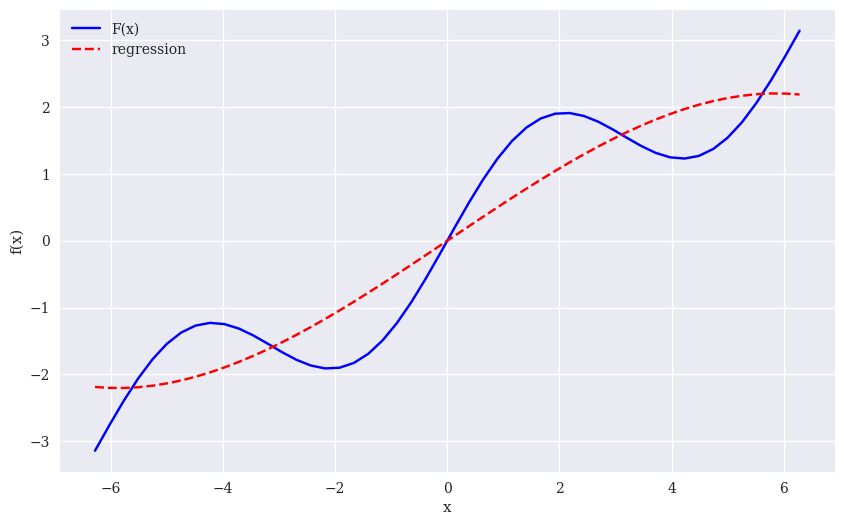

In [ ]:
create_plot([x,x],[f(x),ry],['b','r--'],['F(x)','regression'],['x','f(x)'])

The result in Figure above is not as good as expected based on our previous experience.
with monomials. Using the more general approach allows us to exploit knowledge
about the example function—namely that there is a sin part in the function. Therefore, it makes sense to include a sine function in the set of basis functions. For simplicity, the highest-order monomial is replaced. The fit now is perfect, as the numbers

In [24]:
matrix[3,:] = np.sin(x)

In [26]:
reg = np.linalg.lstsq(matrix.T,f(x),rcond=None)[0]

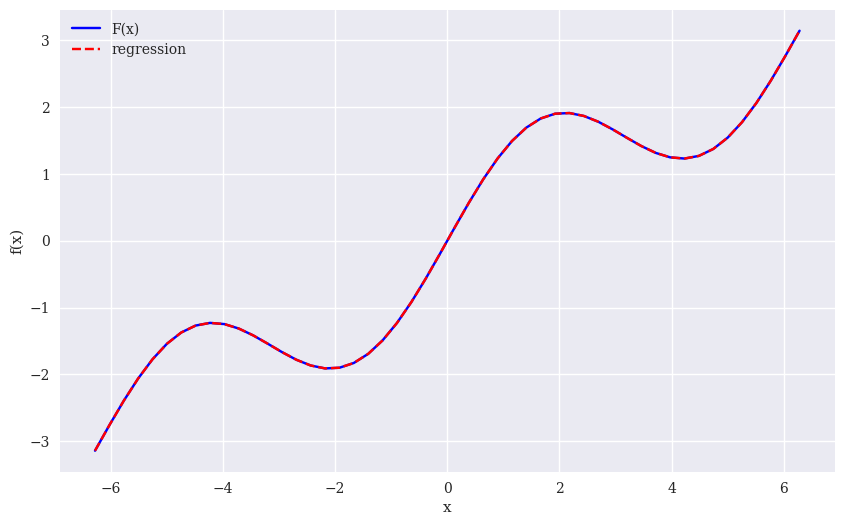

In [27]:
ry = np.dot(reg,matrix)
create_plot([x,x],[f(x),ry],['b','r--'],['F(x)','regression'],['x','f(x)'])

In [29]:
np.allclose(f(x),ry)

True

### Noisy data

Regression can cope equally well with noisy data, be it data from simulation or from
(nonperfect) measurements. To illustrate this point, independent observations with
noise and dependent observations with noise are generated. Figure below reveals that
the regression results are closer to the original function than the noisy data points. In
a sense, the regression averages out the noise to some extent

In [30]:
xn = np.linspace(-2*np.pi,2*np.pi,50)
xn = xn + 0.15 * np.random.standard_normal(len(xn))
yn = f(xn) + 0.25* np.random.standard_normal(len(xn))

In [31]:
reg = np.polyfit(xn,yn,7)
ry = np.polyval(reg,xn)

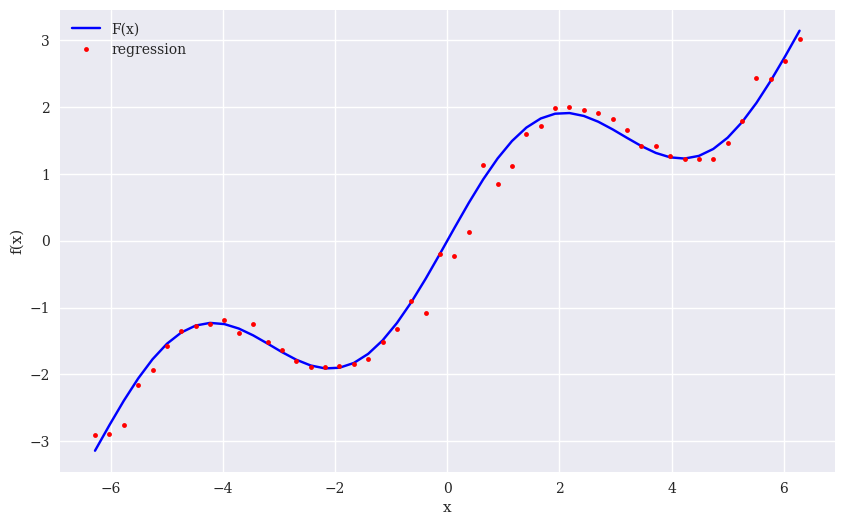

In [34]:
create_plot([x,x],[f(x),ry],['b','r.'],['F(x)','regression'],['x','f(x)'])

### Unsorted data 

Another important aspect of regression is that the approach also works seamlessly
with unsorted data. The previous examples all rely on sorted x data. This does not
have to be the case. To make the point, let’s look at yet another randomization
approach for the x values. In this case, one can hardly identify any structure by just
visually inspecting the raw data

In [37]:
xu = np.random.rand(50) * 4 * np.pi  - 2* np.pi
yu = f(xu)


In [39]:
print(xu[:].round(2))
print(yu[:].round(2))

[-5.55  4.28 -1.64 -5.6  -1.31 -1.37 -3.08 -0.17  1.43 -5.95  2.16  0.48
  0.69  2.11 -2.13  4.41 -0.63 -0.85  6.    4.13  1.09 -1.33 -4.82  2.73
 -4.98 -4.25 -0.33  2.09 -6.   -3.47 -5.81  4.08 -4.43  1.98 -2.8   2.15
 -5.54  3.91  5.63 -6.24 -5.05  4.49  0.79  3.98  1.83  0.15  4.15  1.33
 -3.01 -4.77]
[-2.11  1.23 -1.82 -2.17 -1.62 -1.67 -1.6  -0.25  1.71 -2.64  1.91  0.7
  0.99  1.91 -1.91  1.25 -0.91 -1.18  2.72  1.23  1.44 -1.63 -1.42  1.76
 -1.53 -1.23 -0.49  1.91 -2.72 -1.41 -2.45  1.23 -1.26  1.91 -1.74  1.91
 -2.09  1.26  2.2  -3.08 -1.59  1.27  1.11  1.25  1.88  0.23  1.23  1.64
 -1.64 -1.39]


In [40]:
reg = np.polyfit(xu,yu,5) # remeber its polyfit 
ry = np.polyval(reg,xu)

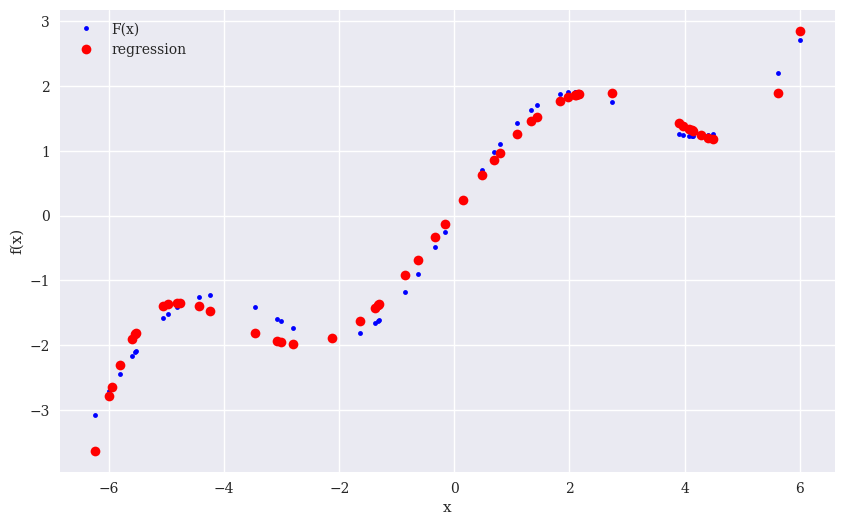

In [51]:
create_plot([xu,xu],[yu,ry],['b.','ro'],['F(x)','regression'],['x','f(x)'])

### Multiple Dimension

Another convenient characteristic of the least-squares regression approach is that it
carries over to multiple dimensions without too many modifications. As an example
function take fm(), as presented next:

In [52]:
def fm(p):
    x,y = p
    return np.sin(x) + 0.25 * x + np.sqrt(y) + 0.05 * y ** 2


In [ ]:
x = np.linspace(0,10,20)
y = np.linspace(0,10,20)
X,Y = np.meshgrid(x,y) # generates the 2D ndarray objects ('Grids")

Z = fm((X,Y))
x = X.flatten() # yields 1 d array objects from the 2D ndarray objects
y = Y.flatten()

In [54]:
from mpl_toolkits.mplot3d import Axes3D

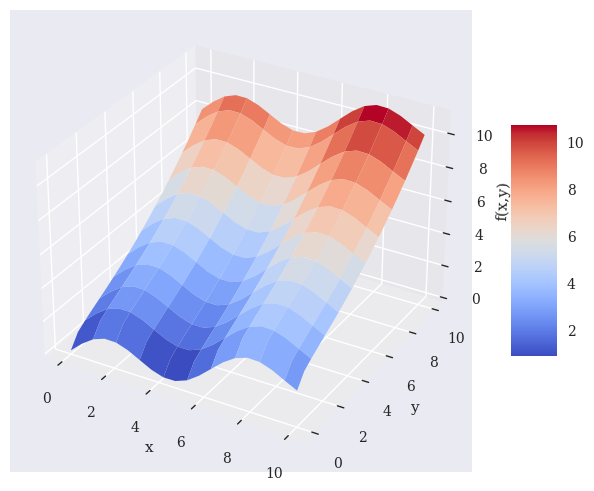

In [61]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
surf = ax.plot_surface(X,Y,Z, 
               rstride = 2 ,cstride =2,
               cmap = 'coolwarm', linewidth = 0.5,
               antialiased = True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
fig.colorbar(surf,shrink=0.5,aspect =5)

In [78]:
matrix = np.zeros((len(x),6+1))
matrix[:,6] = np.sqrt(y)
matrix[:,5] = np.sin(x)
matrix[:,4] = y**2
matrix[:,3] = x**2
matrix[:,2] = y
matrix[:,1] = x
matrix[:,0] = 1

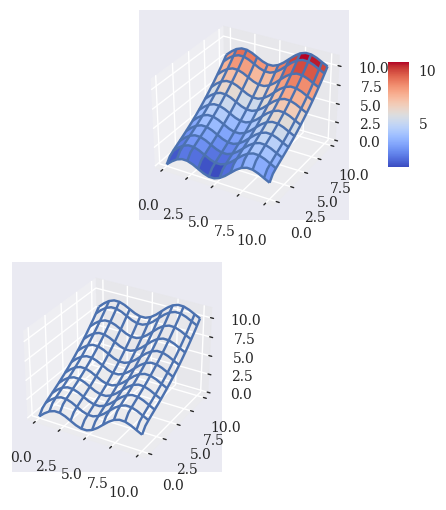

In [83]:
reg = np.linalg.lstsq(matrix,fm((x,y)),rcond=None)[0]
#Transforms the regression results to the grid structure
RZ = np.dot(matrix,reg).reshape((20,20))

fig = plt.figure(figsize=(10,6))

ax1 = fig.add_subplot(211,projection='3d')
ax2 = fig.add_subplot(212,projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, rstride=2, cstride=2,
 cmap=mpl.cm.coolwarm, linewidth=0.5,
 antialiased=True)
surf2 = ax1.plot_wireframe(X, Y, RZ, rstride=2, cstride=2,
 label='regression') 
surf2 = ax2.plot_wireframe(X, Y, RZ, rstride=2, cstride=2,
 label='regression')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.legend()
fig.colorbar(surf1, shrink=0.5, aspect=5)


In [84]:
np.allclose(RZ,fm((X,Y)))

True

### Interpolation

Compared to regression, interpolation (e.g., with cubic splines) is more involved
mathematically. It is also limited to low-dimensional problems. Given an ordered set
of observation points (ordered in the x dimension), the basic idea is to do a regres‐
sion between two neighboring data points in such a way that not only are the data
points perfectly matched by the resulting piecewise-defined interpolation function,
but also the function is continuously differentiable at the data points. Continuous dif‐
ferentiability requires at least interpolation of degree 3—i.e., with cubic splines. How‐
ever, the approach also works in general with quadratic and even linear splines.

In [87]:
import scipy.interpolate as spi

True

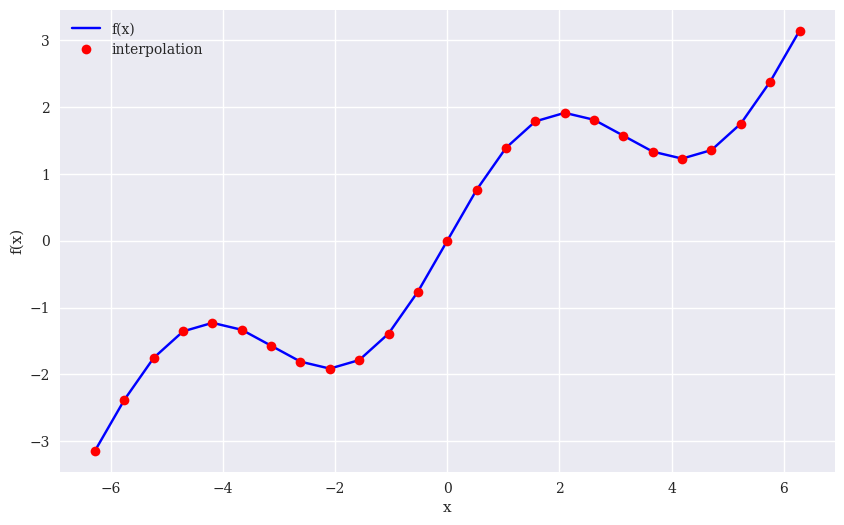

In [98]:
x = np.linspace(-2*np.pi,2*np.pi,25)
def f(x):
    return np.sin(x) + 0.5 *x
 # Implements the linear spline interpolation 
ipo = spi.splrep(x,f(x),k=1)
# Derive the interpolated values
iy = spi.splev(x,ipo)

create_plot([x, x], [f(x), iy], ['b', 'ro'],
 ['f(x)', 'interpolation'], ['x', 'f(x)'])

np.allclose(f(x),iy)

In [99]:
np.mean((f(x)-iy)**2)

np.float64(0.0)

The application itself, given an x-ordered set of data points, is as simple as the appli‐
cation of np.polyfit() and np.polyval(). Here, the respective functions are sci.splrep() and sci.splev().

![paramters that this functions takes as input](new.png)

Spline interpolation is often used in finance to generate estimates for dependent val‐
ues of independent data points not included in the original observations. To this end,
the next example picks a much smaller interval and has a closer look at the interpola‐
ted values with the linear splines.

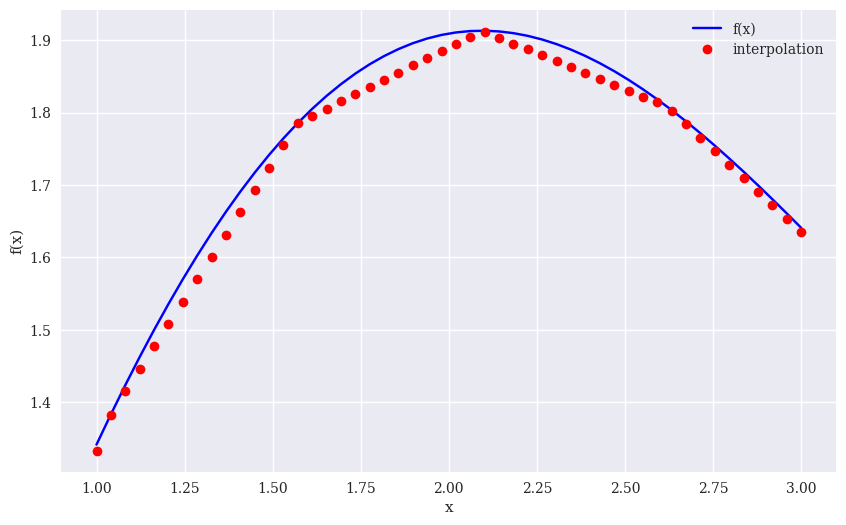

In [100]:
xd = np.linspace(1.0,3.0,50)
iyd = spi.splev(xd,ipo)

create_plot([xd,xd],[f(xd),iyd],['b','ro'],['f(x)', 'interpolation'], ['x', 'f(x)'])

it is evident that the function is not
continuously differentiable at the original data points—another drawback:

A repetition of the complete exercise, this time using cubic splines, improves the
results considerably

In [109]:
ipo = spi.splrep(x,f(x),k=3)
iyd = spi.splev(xd,ipo)

In [110]:
np.allclose(f(xd),iyd)

False

In [111]:
np.mean((f(xd)-iyd)**2)

np.float64(1.1349319851436252e-08)

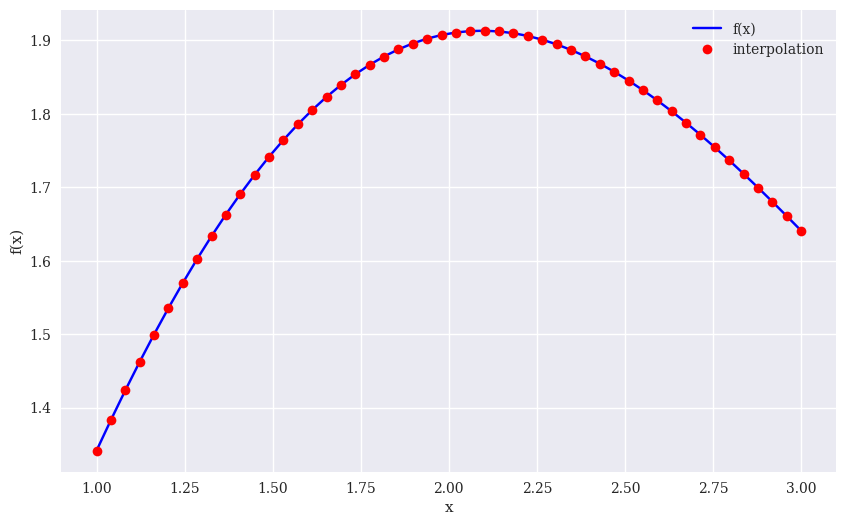

In [112]:

create_plot([xd,xd],[f(xd),iyd],['b','ro'],['f(x)', 'interpolation'], ['x', 'f(x)'])

#### Last Note 

In those cases where spline interpolation can be applied, one can
expect better approximation results compared to a least-squares
regression approach. However, remember that sorted (and “nonnoisy”) data is required and that the approach is limited to lowdimensional problems. It is also computationally more demanding
and might therefore take (much) longer than regression in certain
use cases.


## Convex Optimisation

In finance and economics, convex optimization plays an important role. Examples are
the calibration of option pricing models to market data or the optimization of an
agent’s utility function. As an example, take the function fm()

In [113]:
def fm(p):
    x,y = p
    return (np.sin(x)+0.05*x ** 2+ np.sin(y)+ 0.05*y**2)


x= np.linspace(-10,10,50)
y = np.linspace(-10,10,50)

X,Y = np.meshgrid(x,y)

Z = fm((X,Y))


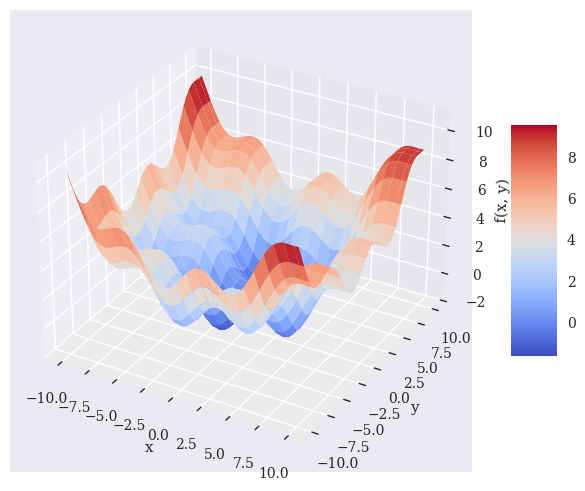

In [114]:
fig = plt.figure(figsize=(10,6))

ax = fig.add_subplot(111,projection='3d')
surf = ax.plot_surface( X,Y,Z, rstride=2, cstride=2,
 cmap='coolwarm', linewidth=0.5,
 antialiased=True)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)


## Integration 

## Symbolic Computation